In [ ]:
# NOTE: This notebook is used for the initial data pre-processing, which will then be used in deconvolution.
# Here, raw data is loaded, and malignant cells are spatially aggregated using the grid-based procedure described in the Methods section of the manuscript.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
import warnings
warnings.filterwarnings("ignore")

import anndata as ad

from utils.processing_utils import create_anndata_object, remove_non_expressive_cells, normalize_for_deconvolution

In [2]:
# Load all required data files
print("Loading raw data files...")

# Load expression data
with open("data_raw/cd_all.json", "rb") as file:
    count_data = json.load(file) 

with open("data_raw/tpm_all.json", "rb") as file:
    tpm_data = json.load(file)

with open("data_raw/genes.json", "rb") as file:
    genes = json.load(file)
genes = [item.upper() for item in genes]  # ensure consistency

# Load cell identifiers and coordinates
with open("data_raw/cells.json", "rb") as file:
    cells = json.load(file)

with open("data_raw/coor.json", "rb") as file:
    coor = json.load(file)

with open("data_raw/cell_types.json", "rb") as file:
    cell_types = json.load(file)

# Load patient and frame information
with open("data_raw/patients.json", "rb") as file:
    patients = json.load(file)

with open("data_raw/frames.json", "rb") as file:
    frames = json.load(file)

with open("data_raw/TMAs.json", "rb") as file:
    tma = json.load(file)

with open("data_raw/frames_metadata.json", "rb") as file:
    frames_metadata = json.load(file)


adata_full = create_anndata_object(coor, cell_types, patients, frames, tma, cells, count_data, tpm_data, genes, frames_metadata)

Loading raw data files...
Expression matrix shape: (491792, 979)
Total gene IDs available: 979
Data loaded successfully.
Dropping cells with Frame_QC == False
Dropping low confidence cells.
Cells after QC: 412916
AnnData object created: AnnData object with n_obs × n_vars = 412916 × 979
    obs: 'Local_x', 'Local_y', 'Local_row', 'Cell_type', 'Patient', 'Frame', 'TMA', 'Cell_ID', 'Frame_no_cells', 'Frame_x', 'Frame_y', 'Frame_size', 'Frame_cell_dens'
    layers: 'counts'


In [3]:
adata_full.obs.head(15)

,Local_x,Local_y,Local_row,Cell_type,Patient,Frame,TMA,Cell_ID,Frame_no_cells,Frame_x,Frame_y,Frame_size,Frame_cell_dens
0,1493.3500,3151.233,SMI_T10_F001_c1017,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1017,94,490.060,494.735,242449.8341,0.0388
1,850.5670,3143.833,SMI_T10_F001_c1062,Malignant,HGSC1,SMI_T10_F001_X2_Y7,T10,SMI_T10_F001_c1062,99,496.000,486.683,241394.7680,0.0410
2,3222.7300,3152.586,SMI_T10_F001_c1064,Malignant,HGSC1,SMI_T10_F001_X7_Y7,T10,SMI_T10_F001_c1064,91,487.160,490.669,239034.3100,0.0381
3,78.0125,3179.012,SMI_T10_F001_c1075,Malignant,HGSC1,SMI_T10_F001_X1_Y7,T10,SMI_T10_F001_c1075,81,485.395,482.586,234244.8315,0.0346
4,1169.2200,3156.375,SMI_T10_F001_c1079,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1079,94,490.060,494.735,242449.8341,0.0388
5,1757.9800,3145.375,SMI_T10_F001_c1093,Malignant,HGSC1,SMI_T10_F001_X4_Y7,T10,SMI_T10_F001_c1093,107,486.850,488.605,237877.3442,0.0450
6,1279.5800,3145.833,SMI_T10_F001_c1106,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1106,94,490.060,494.735,242449.8341,0.0388
7,2708.4200,3107.967,SMI_T10_F001_c1138,Fibroblast,HGSC1,SMI_T10_F001_X6_Y7,T10,SMI_T10_F001_c1138,65,488.230,497.840,243060.4232,0.0267
8,1364.9400,3131.608,SMI_T10_F001_c1145,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1145,94,490.060,494.735,242449.8341,0.0388
9,670.8400,3107.900,SMI_T10_F001_c1154,Malignant,HGSC1,SMI_T10_F001_X2_Y7,T10,SMI_T10_F001_c1154,99,496.000,486.683,241394.7680,0.0410


In [4]:
# What type of cells are we dealing with?

adata_full.obs["Cell_type"].unique()

array(['Malignant', 'Fibroblast', 'Monocyte', 'TNK.cell', 'B.cell',
       'Endothelial', 'Mast.cell'], dtype=object)

In [5]:
# At this point, we are only interested in the Malignant cells.

adata_malignant = adata_full[adata_full.obs["Cell_type"] == "Malignant"].copy()

# Only keep the target genes that are overalpping wiht the OxC gene set.
target_genes = ['APOA1', 'DCN', 'DPP4', 'ENG', 'IGFBP5', 'IGFBP6', 'IL1B', 'IL1RN', 'KRT23', 'LDLR', 'MGP', 'MYH11', 'PIGR', 'PTGS1', 'RAMP1', 'RGS5', 'S100A4', 'SPP1', 'TPM2', 'UBE2C']

adata_malignant = adata_malignant[:, adata_malignant.var_names.isin(target_genes)]

# Then, remove the non-expressive cells and normalize for deconvolution
adata_malignant = remove_non_expressive_cells(adata_malignant)
adata_malignant = normalize_for_deconvolution(adata_malignant)

In [6]:
# inspect the new adata object
adata_malignant

AnnData object with n_obs × n_vars = 267270 × 20
    obs: 'Local_x', 'Local_y', 'Local_row', 'Cell_type', 'Patient', 'Frame', 'TMA', 'Cell_ID', 'Frame_no_cells', 'Frame_x', 'Frame_y', 'Frame_size', 'Frame_cell_dens'
    layers: 'counts', 'normalized_counts'

Text(70.72222222222221, 0.5, 'Genes')

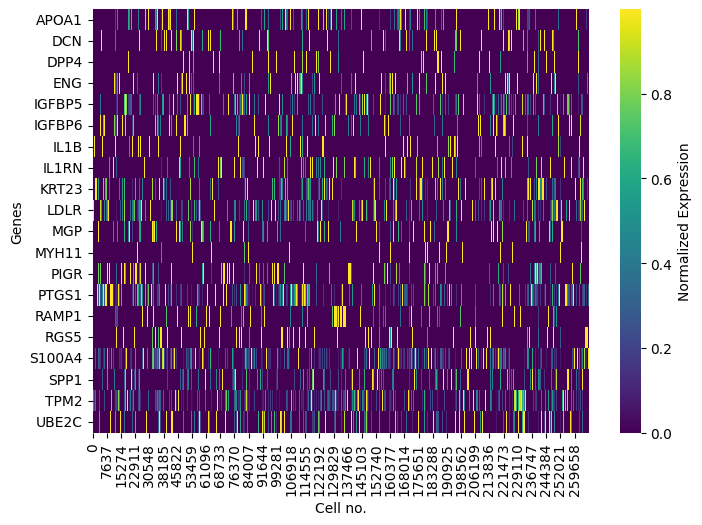

In [7]:
# What does the normalized expression matrix look like?
plt.figure(figsize=(8, 5.5))
sns.heatmap(adata_malignant.layers["normalized_counts"].T, yticklabels = target_genes, cbar_kws={'label': 'Normalized Expression'}, cmap='viridis')
plt.xlabel("Cell no.")
plt.ylabel("Genes")

In [8]:
adata_malignant.obs

# Note, these are just the malignant cells.

,Local_x,Local_y,Local_row,Cell_type,Patient,Frame,TMA,Cell_ID,Frame_no_cells,Frame_x,Frame_y,Frame_size,Frame_cell_dens
0,1493.3500,3151.233,SMI_T10_F001_c1017,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1017,94,490.0600,494.735,242449.8341,0.0388
1,850.5670,3143.833,SMI_T10_F001_c1062,Malignant,HGSC1,SMI_T10_F001_X2_Y7,T10,SMI_T10_F001_c1062,99,496.0000,486.683,241394.7680,0.0410
2,3222.7300,3152.586,SMI_T10_F001_c1064,Malignant,HGSC1,SMI_T10_F001_X7_Y7,T10,SMI_T10_F001_c1064,91,487.1600,490.669,239034.3100,0.0381
3,78.0125,3179.012,SMI_T10_F001_c1075,Malignant,HGSC1,SMI_T10_F001_X1_Y7,T10,SMI_T10_F001_c1075,81,485.3950,482.586,234244.8315,0.0346
4,1169.2200,3156.375,SMI_T10_F001_c1079,Malignant,HGSC1,SMI_T10_F001_X3_Y7,T10,SMI_T10_F001_c1079,94,490.0600,494.735,242449.8341,0.0388
...,...,...,...,...,...,...,...,...,...,...,...,...,...
412903,5038.3500,1097.520,SMI_T14_F020_c4486,Malignant,HGSC89,SMI_T14_F020_X11_Y3,T14,SMI_T14_F020_c4486,72,446.0500,497.750,222021.3875,0.0324
412904,2705.3900,393.120,SMI_T14_F020_c5823,Malignant,HGSC89,SMI_T14_F020_X6_Y1,T14,SMI_T14_F020_c5823,77,491.7400,488.200,240067.4680,0.0321
412906,2756.8000,11.560,SMI_T14_F020_c6537,Malignant,HGSC89,SMI_T14_F020_X6_Y1,T14,SMI_T14_F020_c6537,77,491.7400,488.200,240067.4680,0.0321
412907,196.6750,3124.425,SMI_T14_F020_c828,Malignant,HGSC89,SMI_T14_F020_X1_Y7,T14,SMI_T14_F020_c828,68,482.5503,496.200,239441.4589,0.0284


In [9]:
# Aggregate the malignant cells using a grid-based approach
from utils.processing_utils import process_spatial_data

aggregated_malignant_df = process_spatial_data(adata_malignant)

Processing patients: 100%|██████████| 58/58 [00:32<00:00,  1.77it/s]


In [14]:
aggregated_malignant_df.head(10)

,Patient_ID,Frame,Grid_X_Y,No_cells,Cell_names,APOA1,DCN,DPP4,ENG,IGFBP5,...,MGP_raw,MYH11_raw,PIGR_raw,PTGS1_raw,RAMP1_raw,RGS5_raw,S100A4_raw,SPP1_raw,TPM2_raw,UBE2C_raw
0,HGSC1,F001,0_0,19,"SMI_T10_F001_c7207,SMI_T10_F001_c7287,SMI_T10_...",1.573922,2.668908,0.934569,2.999990,1.109909,...,4.0,0.0,0.0,2.0,1.0,1.0,5.0,1.0,20.0,8.0
1,HGSC1,F001,0_1,14,"SMI_T10_F001_c6601,SMI_T10_F001_c6744,SMI_T10_...",0.589779,1.999994,0.999998,1.535002,0.635354,...,1.0,0.0,1.0,6.0,1.0,1.0,6.0,2.0,12.0,7.0
2,HGSC1,F001,0_2,19,"SMI_T10_F001_c6459,SMI_T10_F001_c6106,SMI_T10_...",1.837428,1.999994,0.999998,0.000000,0.870693,...,4.0,0.0,2.0,1.0,2.0,2.0,3.0,4.0,18.0,5.0
3,HGSC1,F001,0_3,25,"SMI_T10_F001_c5654,SMI_T10_F001_c5766,SMI_T10_...",3.707808,0.000000,1.977611,0.000000,0.000000,...,2.0,0.0,1.0,6.0,2.0,4.0,4.0,1.0,13.0,10.0
4,HGSC1,F001,0_4,23,"SMI_T10_F001_c5346,SMI_T10_F001_c5170,SMI_T10_...",1.729487,0.963116,1.999996,0.000000,1.401605,...,0.0,0.0,1.0,5.0,1.0,1.0,4.0,3.0,8.0,6.0
5,HGSC1,F001,0_5,19,"SMI_T10_F001_c4441,SMI_T10_F001_c4446,SMI_T10_...",3.653542,0.000000,0.000000,2.587198,2.174923,...,0.0,0.0,2.0,5.0,0.0,1.0,4.0,10.0,15.0,6.0
6,HGSC1,F001,0_6,7,"SMI_T10_F001_c4188,SMI_T10_F001_c3865,SMI_T10_...",0.000000,0.999997,0.999998,1.999992,1.020003,...,2.0,1.0,0.0,2.0,1.0,0.0,3.0,1.0,7.0,2.0
7,HGSC1,F001,0_7,19,"SMI_T10_F001_c3456,SMI_T10_F001_c3459,SMI_T10_...",4.089646,0.000000,1.999996,0.999996,1.392921,...,2.0,1.0,3.0,3.0,0.0,2.0,6.0,16.0,17.0,6.0
8,HGSC1,F001,0_8,16,"SMI_T10_F001_c2898,SMI_T10_F001_c3110,SMI_T10_...",1.176856,0.000000,2.999993,1.535000,0.171218,...,3.0,0.0,3.0,5.0,3.0,1.0,9.0,11.0,19.0,3.0
9,HGSC1,F001,0_9,18,"SMI_T10_F001_c2230,SMI_T10_F001_c2232,SMI_T10_...",1.729487,1.775501,0.000000,0.999996,1.477923,...,2.0,0.0,1.0,6.0,0.0,0.0,3.0,0.0,15.0,4.0


In [11]:
aggregated_malignant_df.head()

,Patient_ID,Frame,Grid_X_Y,No_cells,Cell_names,APOA1,DCN,DPP4,ENG,IGFBP5,...,MGP_raw,MYH11_raw,PIGR_raw,PTGS1_raw,RAMP1_raw,RGS5_raw,S100A4_raw,SPP1_raw,TPM2_raw,UBE2C_raw
0,HGSC1,F001,0_0,19,"SMI_T10_F001_c7207,SMI_T10_F001_c7287,SMI_T10_...",1.573922,2.668908,0.934569,2.999990,1.109909,...,4.0,0.0,0.0,2.0,1.0,1.0,5.0,1.0,20.0,8.0
1,HGSC1,F001,0_1,14,"SMI_T10_F001_c6601,SMI_T10_F001_c6744,SMI_T10_...",0.589779,1.999994,0.999998,1.535002,0.635354,...,1.0,0.0,1.0,6.0,1.0,1.0,6.0,2.0,12.0,7.0
2,HGSC1,F001,0_2,19,"SMI_T10_F001_c6459,SMI_T10_F001_c6106,SMI_T10_...",1.837428,1.999994,0.999998,0.000000,0.870693,...,4.0,0.0,2.0,1.0,2.0,2.0,3.0,4.0,18.0,5.0
3,HGSC1,F001,0_3,25,"SMI_T10_F001_c5654,SMI_T10_F001_c5766,SMI_T10_...",3.707808,0.000000,1.977611,0.000000,0.000000,...,2.0,0.0,1.0,6.0,2.0,4.0,4.0,1.0,13.0,10.0
4,HGSC1,F001,0_4,23,"SMI_T10_F001_c5346,SMI_T10_F001_c5170,SMI_T10_...",1.729487,0.963116,1.999996,0.000000,1.401605,...,0.0,0.0,1.0,5.0,1.0,1.0,4.0,3.0,8.0,6.0


Plotting patients:   0%|          | 0/58 [00:00<?, ?it/s]


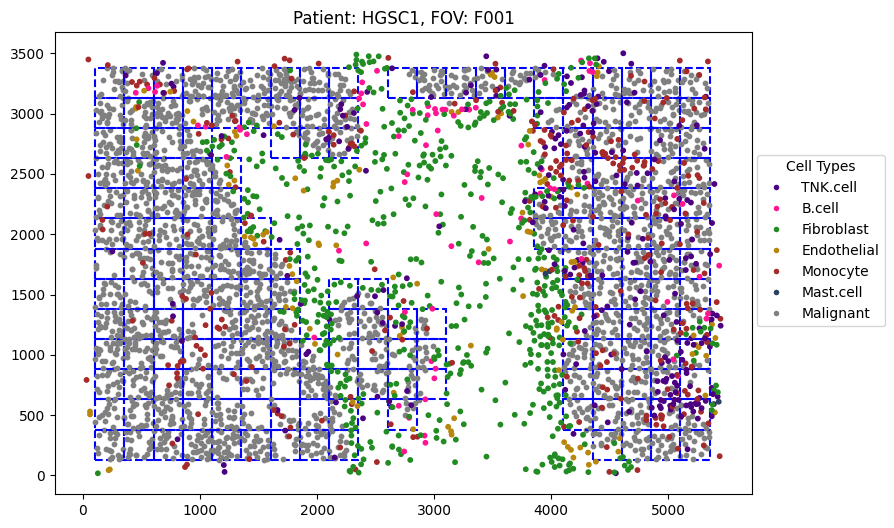

In [ ]:
# Ok, now we can focus on the spatial grids.
from utils.plotting_utils import plot_spatial_grid

plot_spatial_grid(adata_full, adata_malignant,
                  grid_size = 250,
                  min_cells = 3,
                  fig_size = (9, 6),
                  markersize = 10,
                  save_path = "data_processed/spatial_grids"
                  legend = True,
                  close = False)

In [ ]:
# Save the anndata objects and the aggregated dataframe
# import pickle as pkl

# adata_full.write("data_processed/adata_full.h5ad")
# adata_malignant.write("data_processed/adata_malignant.h5ad")

# with open("data_processed/aggregated_malignant_df.pkl", "wb") as file:
#     pkl.dump(aggregated_malignant_df, file)

#### Final plot
____

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import pickle as pkl

In [ ]:
with open("data_processed/aggregated_malignant_df.pkl", "rb") as file:
    aggregated_malignant_df = pkl.load(file)

gene_names = ['APOA1', 'DCN', 'DPP4', 'ENG', 'IGFBP5', 'IGFBP6', 'IL1B', 'IL1RN', 'KRT23', 'LDLR', 'MGP', 'MYH11', 'PIGR', 'PTGS1', 'RAMP1', 'RGS5', 'S100A4', 'SPP1', 'TPM2', 'UBE2C']

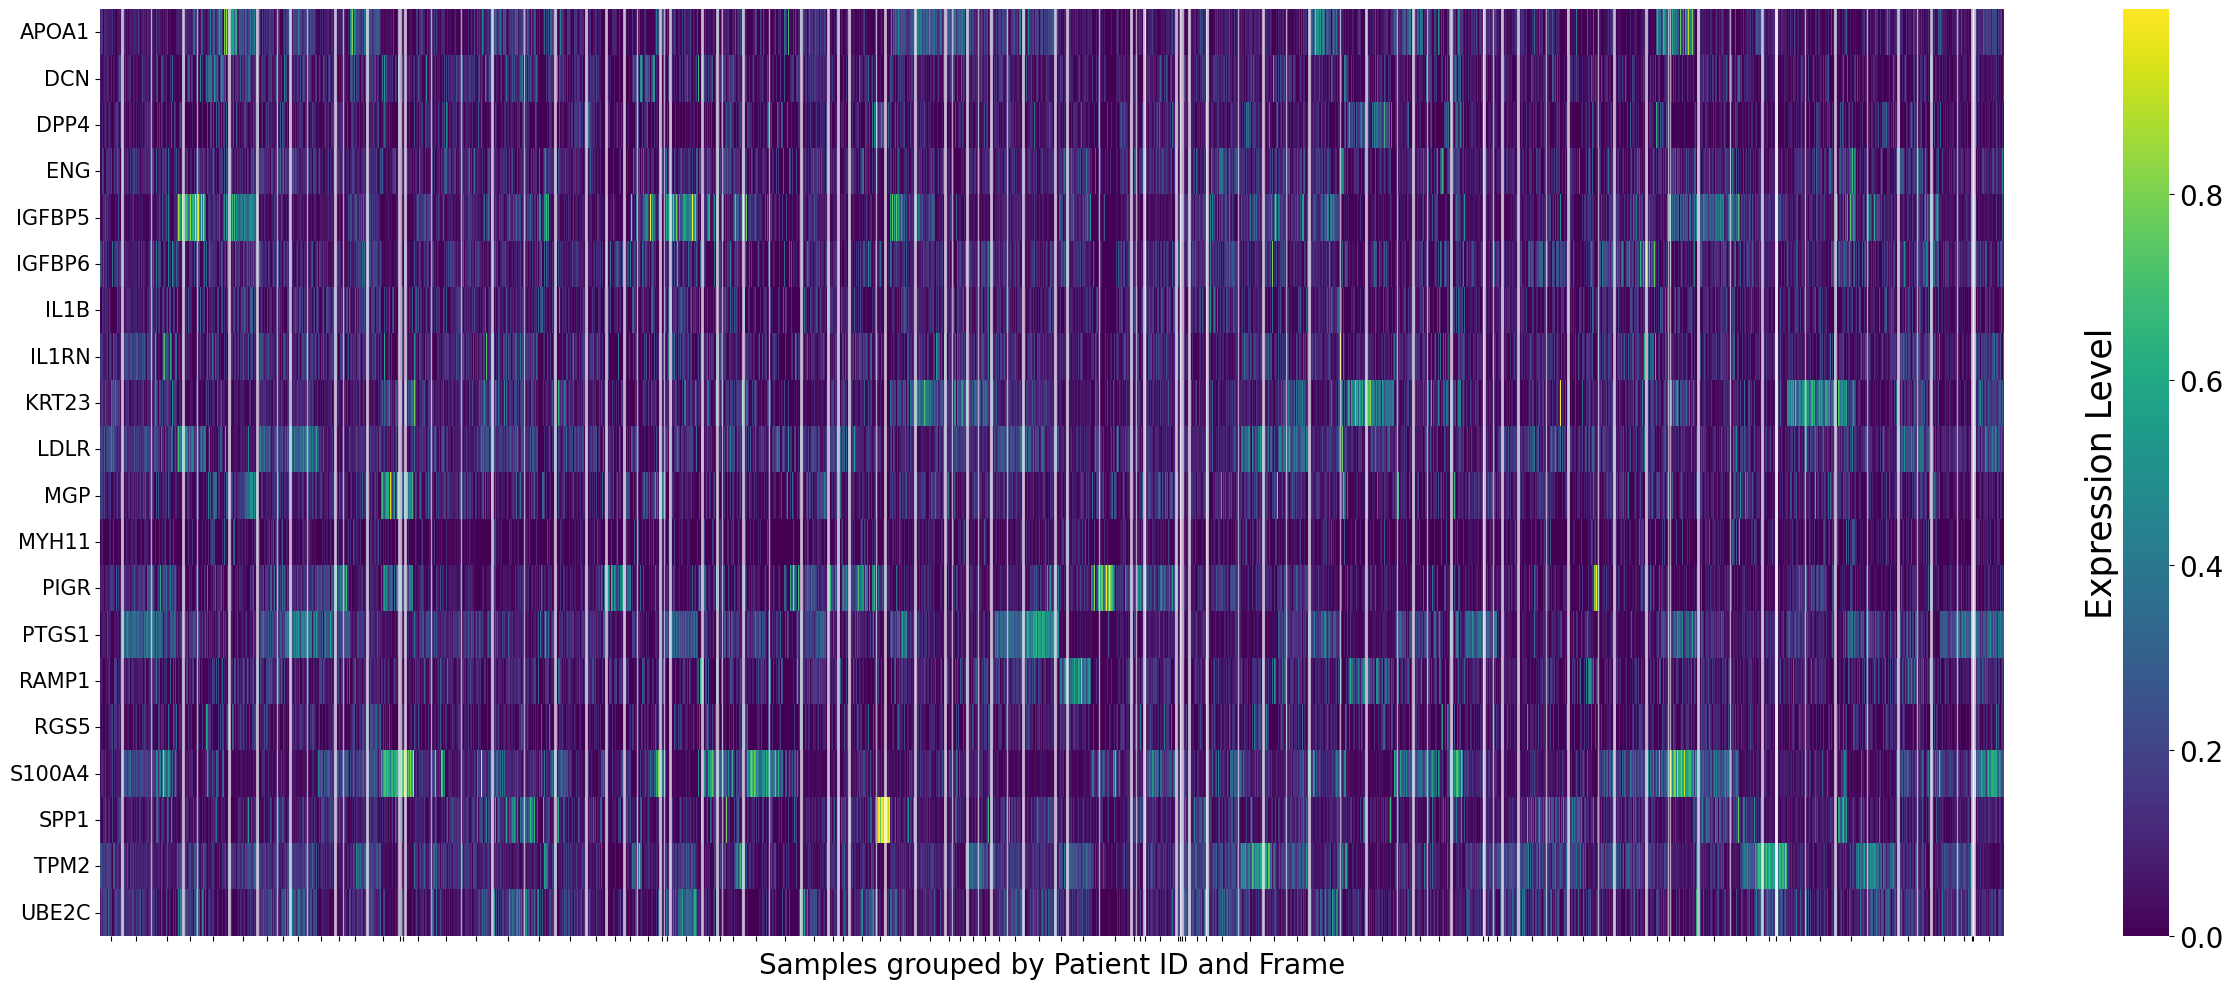

In [5]:
def plot_expression_matrix(df, gene_names, figsize, display_xticks = False, generic_xlabel = True):
    plt.figure(figsize = figsize)

    # normalize the data
    data = df[gene_names]
    data_norm = data / aggregated_malignant_df["No_cells"].to_numpy()[:, None]

        
    # Create the heatmap
    ax = sns.heatmap(data_norm.T, annot=False, cmap="viridis", xticklabels=[], yticklabels=gene_names, cbar_kws= {"label": "Expression Level"})

    cbar = ax.collections[0].colorbar
    cbar.set_label('Expression Level', size=25, labelpad = -100)
    cbar.ax.tick_params(labelsize=20)  # Also 


    # Calculate tick positions and labels programmatically
    tick_positions = []
    tick_labels = []
    separator_positions = []

    plt.yticks(fontsize = 15)

    # Group by Patient_ID and Frame to find boundaries
    grouped = df.groupby(['Patient_ID', 'Frame'])

    current_pos = 0
    previous_patient = None
    previous_frame = None

    for (patient, frame), group in grouped:
        group_size = len(group)
        
        # Calculate center position for this group
        center_pos = current_pos + (group_size - 1) / 2
        tick_positions.append(center_pos)
        tick_labels.append(f"{patient} {frame}")
        
        # Add separator line for:
        # 1. Different patients (thicker line)
        # 2. Different frames within the same patient (thinner line)
        if previous_patient is not None:
            if previous_patient != patient:
                # Different patient - add thick separator
                separator_positions.append((current_pos, 'patient'))
            elif previous_frame != frame:
                # Same patient, different frame - add thin separator
                separator_positions.append((current_pos, 'frame'))
        
        previous_patient = patient
        previous_frame = frame
        current_pos += group_size

    # Add vertical separators with different styles
    for pos, sep_type in separator_positions:
        if sep_type == 'patient':
            plt.axvline(x=pos, color='white', linewidth=2, alpha=0.7)  # Thick line for patients
        else:  # sep_type == 'frame'
            plt.axvline(x=pos, color='white', linewidth=1, alpha=0.6)  # Thin line for frames

    # Set the calculated ticks
    if display_xticks:
        plt.xticks(ticks=tick_positions, labels=tick_labels, rotation = 45, fontsize = 8)
    else:
        plt.xticks(ticks=tick_positions, labels=[], rotation = 45, fontsize = 8)

    if generic_xlabel:
        plt.xlabel('Samples grouped by Patient ID and Frame', fontsize=20)

    plt.tight_layout()

plot_expression_matrix(aggregated_malignant_df, gene_names, figsize = (25, 10), display_xticks=False, generic_xlabel=True)

### Figure caption:
Expression heatmap of selected genes across patient samples. The heatmap displays normalized expression levels of 20 genes(rows) across individual samples (columns) grouped by Patient ID and field of view (FOV). Expression values are normalized by total cell counts in every spatial grid cell. The white vertical lines are strictly used for delimitation purposes. Tick lines are demarcating boundaries between different patients, while thin lines are separating different FOVs from within the same patient.